# deepSSF — train, validate, simulate

End-to-end example using the bundled buffalo GPS dataset and two static raster
covariates (NDVI and slope).  The notebook calls the package throughout.

**Sections**
1. Import data
2. Prepare data
3. Train model
4. Validate against withheld data
5. Simulate a trajectory

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import rasterio

import deepssf
from deepssf import (
    ConvJointModel,
    EarlyStopping,
    ModelParams,
    create_gif,
    fit,
    get_device,
    load_environmental_layers,
    make_dataloaders,
    make_optimisers,
    negativeLogLikeLoss,
    filter_steps_by_window,
    prepare_movement_df,
    simulate_trajectory,
    validate_next_step_probs,
)

import pandas as pd
from datetime import datetime                # Date/time utilities
from IPython.display import Image            # For plotting GIFs
from rasterio.plot import show               # For plotting raster layers

print(f"deepssf {deepssf.__version__}")
print(f"torch {torch.__version__}")

deepssf 0.1.0
torch 2.12.0


In [2]:
# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: mps


## 1  Import data

In [3]:
DATA_DIR = Path("../src/deepssf/datasets/data")
CSV_PATH = DATA_DIR / "buffalo_djelk_id2005.csv"
LAYER_PATHS = {
    "ndvi":  str(DATA_DIR / "ndvi_2005.tif"),
    "slope": str(DATA_DIR / "slope_2005.tif"),
}
OUTPUT_DIR  = Path("outputs")
SNAPSHOT_DIR = OUTPUT_DIR / "training_snapshots"
OUTPUT_DIR.mkdir(exist_ok=True)

In [4]:
raw_df = pd.read_csv(CSV_PATH)
print(f"Raw GPS fixes : {len(raw_df):,}")
print(f"Individuals   : {raw_df['id'].nunique()}")

# Sort by the individual ID and timestamp to ensure correct temporal order
raw_df = raw_df.sort_values(by=["id", "time"]).reset_index(drop=True)

# # Convert the 'time' column to the correct timezone (here Australia/Darwin) 
# raw_df["time"] = (
#         pd.to_datetime(raw_df["time"], utc=True)
#         .dt.tz_convert("Australia/Darwin")
#     )

raw_df.head()

Raw GPS fixes : 10,297
Individuals   : 1


,id,time,x,y
0,2005,2018-07-25T00:04:02Z,41941.331695,-1.435875e+06
1,2005,2018-07-25T01:04:23Z,41969.310875,-1.435671e+06
2,2005,2018-07-25T02:04:39Z,41921.521939,-1.435654e+06
3,2005,2018-07-25T03:04:17Z,41779.439594,-1.435601e+06
4,2005,2018-07-25T04:04:39Z,41841.203272,-1.435635e+06


In [5]:
env_layers, raster_transform = load_environmental_layers(LAYER_PATHS)
print("Layers loaded:", list(env_layers.keys()))
for name, arr in env_layers.items():
    print(f"  {name}: shape={arr.shape}, min={arr.min():.3f}, max={arr.max():.3f}")

Layer 'ndvi': min=-0.06614641100168228, max=0.731696367263794 → scaled to [0, 1]
Layer 'slope': min=0.00013558653881773353, max=12.298083305358887 → scaled to [0, 1]
Layers loaded: ['ndvi', 'slope']
  ndvi: shape=(758, 1175), min=0.000, max=1.090
  slope: shape=(758, 1175), min=0.000, max=1.000


## 2  Prepare data

In [6]:
step_df = prepare_movement_df(raw_df)
print(f"Movement steps : {len(step_df):,}  ({len(raw_df) - len(step_df)} dropped — last fix per individual)")
step_df.head()

Movement steps : 10,296  (1 dropped — last fix per individual)


,id,t1_,x1_,y1_,t2_,x2_,y2_,dx,dy,bearing,bearing_tm1,dt_hour,hour_t1,yday_t1,hour_t1_sin1,hour_t1_cos1,yday_t1_sin1,yday_t1_cos1
0,2005,2018-07-25T00:04:02Z,41941.331695,-1.435875e+06,2018-07-25T01:04:23Z,41969.310875,-1.435671e+06,27.979180,204.064135,1.434536,0.000000,1.005833,0.066667,206.0,0.017452,0.999848,-0.391358,-0.920239
1,2005,2018-07-25T01:04:23Z,41969.310875,-1.435671e+06,2018-07-25T02:04:39Z,41921.521939,-1.435654e+06,-47.788936,16.857110,2.802478,1.434536,1.004444,1.066667,206.0,0.275637,0.961262,-0.391358,-0.920239
2,2005,2018-07-25T02:04:39Z,41921.521939,-1.435654e+06,2018-07-25T03:04:17Z,41779.439594,-1.435601e+06,-142.082345,53.568427,2.781049,2.802478,0.993889,2.066667,206.0,0.515038,0.857167,-0.391358,-0.920239
3,2005,2018-07-25T03:04:17Z,41779.439594,-1.435601e+06,2018-07-25T04:04:39Z,41841.203272,-1.435635e+06,61.763677,-34.322938,-0.507220,2.781049,1.006111,3.066667,206.0,0.719340,0.694658,-0.391358,-0.920239
4,2005,2018-07-25T04:04:39Z,41841.203272,-1.435635e+06,2018-07-25T05:04:27Z,41655.463332,-1.435604e+06,-185.739939,31.003534,2.976198,-0.507220,0.996667,4.066667,206.0,0.874620,0.484810,-0.391358,-0.920239


In [7]:
# Model configuration
# 4 scalar covariates broadcast into spatial maps (no dt_hour so simulate() matches)
SCALAR_COLS = ["hour_t1_sin1", "hour_t1_cos1", "yday_t1_sin1", "yday_t1_cos1", "dt_hour"]
WINDOW_SIZE = 101    # small for speed; 101 is typical for production
PIXEL_SIZE  = 25    # raster resolution in metres (CRS units)
BATCH_SIZE  = 32

# Calculate the flat size of the movement CNN output after 3× conv+maxpool
OUTPUT_CHANNELS = 4
dim = WINDOW_SIZE
for _ in range(3):
    dim = math.floor((dim + 2 * 1 - 3) / 1 + 1)  # conv: pad=1 keeps dim
    dim = math.floor((dim - 2) / 2 + 1)           # maxpool k=2, s=2
DENSE_DIM = OUTPUT_CHANNELS * dim * dim
print(f"After 3× conv+maxpool: dim={dim}  →  dense_dim_in_all={DENSE_DIM}")

# Drop steps whose displacement exceeds the window; would cause an index error in the loss
step_df = filter_steps_by_window(step_df, window_size=WINDOW_SIZE, pixel_size=PIXEL_SIZE)
print(f"Steps after window filter: {len(step_df):,}")


After 3× conv+maxpool: dim=12  →  dense_dim_in_all=576
Steps after window filter: 10,101


In [8]:
dl_train, dl_val, dl_test = make_dataloaders(
    layer_paths=LAYER_PATHS,
    window_size=WINDOW_SIZE,
    batch_size=BATCH_SIZE,
    train_split=0.8,
    val_split=0.1,
    scalar_cols=SCALAR_COLS,
    df=step_df,
)
print(f"Train batches : {len(dl_train)}")
print(f"Val   batches : {len(dl_val)}")
print(f"Test  batches : {len(dl_test)}")

Layer 'ndvi': min=-0.06614641100168228, max=0.731696367263794 → scaled to [0, 1]
Layer 'slope': min=0.00013558653881773353, max=12.298083305358887 → scaled to [0, 1]
Train batches : 253
Val   batches : 32
Test  batches : 32


/Users/scottforrest/Library/Mobile Documents/com~apple~CloudDocs/github_repos/deepSSF_package/src/deepssf/data.py:358: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self.scalar_to_grid_data = torch.from_numpy(


In [9]:
# Inspect one batch
x1, x2, x3, (px2, py2), _ = next(iter(dl_train))
print(f"Spatial   x1 : {x1.shape}   (batch × channels × H × W)")
print(f"Scalars   x2 : {x2.shape}")
print(f"Bearing   x3 : {x3.shape}")
print(f"Next-step px2: {px2[:4].tolist()}  py2: {py2[:4].tolist()}")

Spatial   x1 : torch.Size([32, 2, 101, 101])   (batch × channels × H × W)
Scalars   x2 : torch.Size([32, 5])
Bearing   x3 : torch.Size([32, 1])
Next-step px2: [54, 51, 50, 50]  py2: [51, 53, 50, 50]


## 3  Train model

In [10]:
params = ModelParams({
    "batch_size":                BATCH_SIZE,
    "image_dim":                 WINDOW_SIZE,
    "pixel_size":                PIXEL_SIZE,
    "dim_in_nonspatial_to_grid": len(SCALAR_COLS),
    "dense_dim_in_nonspatial":   len(SCALAR_COLS),
    "dense_dim_hidden":          64,
    "dense_dim_in_all":          DENSE_DIM,
    "input_channels":            2 + len(SCALAR_COLS),  # 2 spatial + 4 scalar-to-grid
    "output_channels":           OUTPUT_CHANNELS,
    "kernel_size":               3,
    "stride":                    1,
    "kernel_size_mp":            2,
    "stride_mp":                 2,
    "padding":                   1,
    "num_movement_params":       12,
    "dropout":                   0.0,
    "device":                    DEVICE,
})

model = ConvJointModel(params).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters : {n_params:,}")

Model parameters : 43,009


In [11]:
loss_fn     = negativeLogLikeLoss(reduction="mean")
optimisers, schedulers = make_optimisers(
    model, lr_habitat=1e-4, lr_movement=1e-5, scheduler_patience=2
)
early_stop  = EarlyStopping(
    patience=5, verbose=True, path=str(OUTPUT_DIR / "best_model.pt")
)

In [13]:
history = fit(
    model=model,
    n_conv_layers=4, # how many convolutional layers in the habitat selection process (to filter edge artifacts that affect colour scaling)
    window_size=WINDOW_SIZE,
    dl_train=dl_train,
    dl_val=dl_val,
    loss_fn=loss_fn,
    optimisers=optimisers,
    schedulers=schedulers,
    n_epochs=50,
    early_stopping=early_stop,
    snapshot_dir=str(SNAPSHOT_DIR),
    snapshot_item=500,
)


Epoch 1/50
loss:        6.785439  [   32/ 8081]
loss:        6.097230  [  352/ 8081]
loss:        5.551458  [  672/ 8081]
loss:        5.073307  [  992/ 8081]
loss:        6.436917  [ 1312/ 8081]
loss:        6.255669  [ 1632/ 8081]
loss:        5.437774  [ 1952/ 8081]
loss:        5.842318  [ 2272/ 8081]
loss:        6.056246  [ 2592/ 8081]
loss:        5.573969  [ 2912/ 8081]
loss:        5.683355  [ 3232/ 8081]
loss:        5.886904  [ 3552/ 8081]
loss:        5.906250  [ 3872/ 8081]
loss:        4.869259  [ 4192/ 8081]
loss:        6.376064  [ 4512/ 8081]
loss:        5.547744  [ 4832/ 8081]
loss:        6.104920  [ 5152/ 8081]
loss:        5.175964  [ 5472/ 8081]
loss:        6.325367  [ 5792/ 8081]
loss:        5.473641  [ 6112/ 8081]
loss:        4.946332  [ 6432/ 8081]
loss:        5.967487  [ 6752/ 8081]
loss:        5.914863  [ 7072/ 8081]
loss:        5.850795  [ 7392/ 8081]
loss:        5.686168  [ 7712/ 8081]
loss:        5.253773  [ 8032/ 8081]

Avg training loss:       

Animation saved: outputs/training_progress.gif
Training GIF → outputs/training_progress.gif


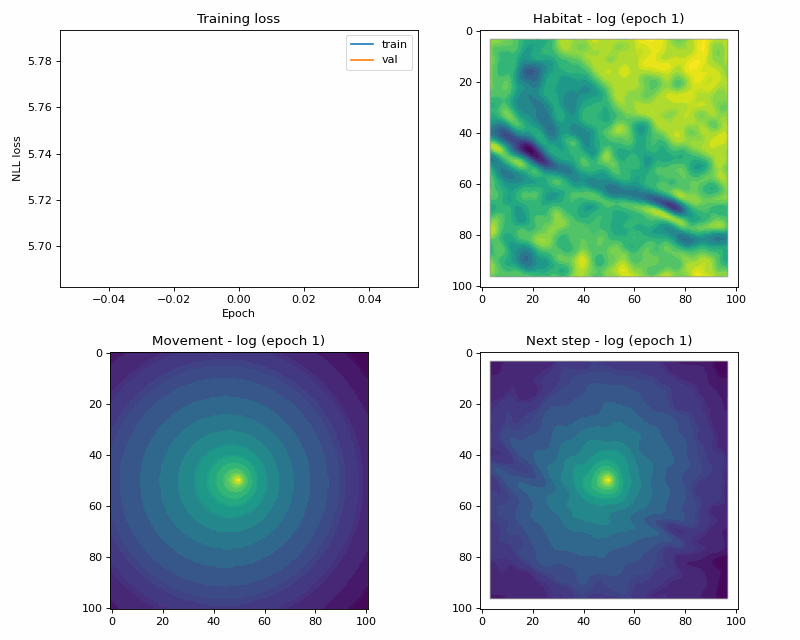

In [22]:
gif_path = str(OUTPUT_DIR / "training_progress.gif")
create_gif(str(SNAPSHOT_DIR), gif_path, fps=5)
print(f"Training GIF → {gif_path}")

# Play the gif
Image(gif_path)

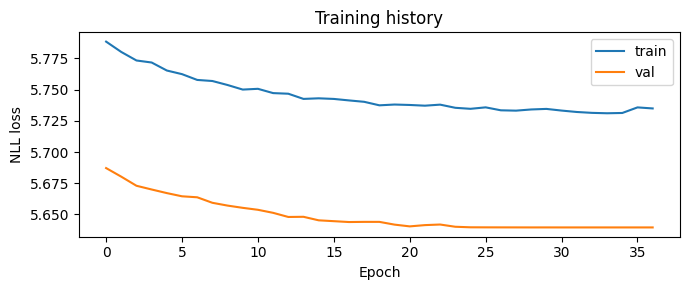

In [23]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history["train_losses"], label="train")
ax.plot(history["val_losses"],   label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("NLL loss")
ax.legend()
ax.set_title("Training history")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "loss_history.png"), dpi=100)
plt.show()

## 4  Validate against withheld test data

In [24]:
# Load the best checkpoint saved during training
model.load_state_dict(
    torch.load(str(OUTPUT_DIR / "best_model.pt"), map_location=DEVICE)
)
model.eval()
print("Best checkpoint loaded.")

Best checkpoint loaded.


In [25]:
# Wrap the static rasters as a landscape-loader callable.
# Month index is ignored here because we have static (non-S2) layers.
ndvi_t  = torch.from_numpy(env_layers["ndvi"].astype(np.float32))
slope_t = torch.from_numpy(env_layers["slope"].astype(np.float32))

def get_landscape(_month_index):
    return [ndvi_t, slope_t]

In [26]:
# Use the last 10 % of steps as the test set (matches the DataLoader split)
n_test      = int(len(step_df) * 0.1)
test_sample = step_df.iloc[-n_test:].reset_index(drop=True)
print(f"Validating on {len(test_sample):,} steps")

val_results = validate_next_step_probs(
    model,
    test_sample,
    get_landscape=get_landscape,
    transform=raster_transform,
    window_size=WINDOW_SIZE,
    scalar_cols=tuple(SCALAR_COLS),
    yday_col="yday_t1",
    bearing_col="bearing_tm1",
    month_index_fn=lambda _yday: 0,   # static layers — month doesn't matter
)
print(val_results[["habitat_prob", "move_prob", "next_step_prob"]].describe())

Validating on 1,010 steps
       habitat_prob    move_prob  next_step_prob
count   1010.000000  1010.000000     1010.000000
mean       0.000126     0.027330        0.030069
std        0.000050     0.054359        0.060509
min        0.000000     0.000000        0.000000
25%        0.000093     0.000224        0.000228
50%        0.000112     0.006624        0.007082
75%        0.000155     0.030587        0.034205
max        0.000430     0.255475        0.334267


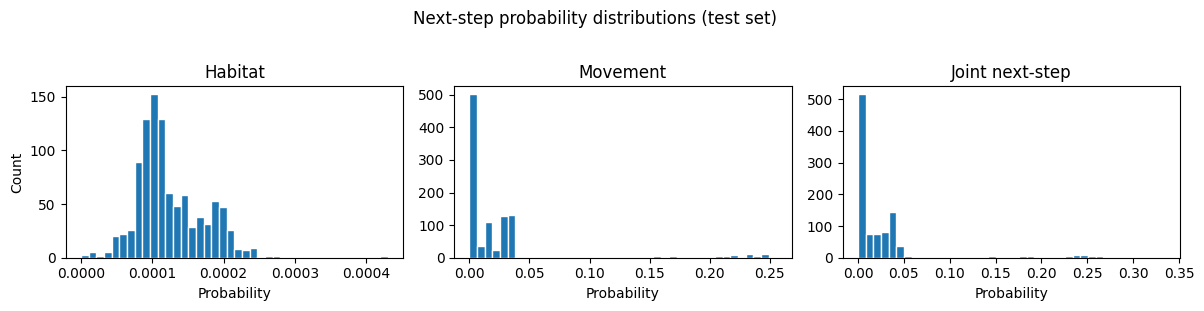

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col, title in zip(
    axes,
    ["habitat_prob", "move_prob", "next_step_prob"],
    ["Habitat", "Movement", "Joint next-step"],
):
    data = val_results[col].dropna()
    ax.hist(data, bins=40, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Probability")
axes[0].set_ylabel("Count")
plt.suptitle("Next-step probability distributions (test set)", y=1.02)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "validation_probs.png"), dpi=100)
plt.show()

## 5  Simulate a trajectory

In [28]:
start_x = float(step_df["x1_"].median())
start_y = float(step_df["y1_"].median())
print(f"Starting location: ({start_x:.0f}, {start_y:.0f})")

sim_df = simulate_trajectory(
    model,
    get_landscape=get_landscape,
    transform=raster_transform,
    start_x=start_x,
    start_y=start_y,
    n_steps=1000,
    starting_yday=test_sample["yday_t1"].iloc[0],
    starting_hour=test_sample["hour_t1"].iloc[0],
    time_between_steps=1.0,
    window_size=WINDOW_SIZE,
    month_index_fn=lambda _yday: 0,   # static layers
)
print(f"Simulated {len(sim_df)} steps")
sim_df.head()

Starting location: (36111, -1436905)
Simulated 1000 steps


,x,y,hour,yday,month_index,hab_log_prob,move_log_prob,step_log_prob
0,36108.269587,-1.436912e+06,18.916667,255.000000,0,"[[-9.412999, -9.240336, -9.038588, -8.982068, ...","[[-13.963823, -13.919329, -13.875055, -13.8310...","[[-23.376823, -23.159664, -22.913643, -22.8130..."
1,35898.710528,-1.436614e+06,19.916667,255.041667,0,"[[-9.405268, -9.207009, -8.999849, -8.948765, ...","[[-13.95573, -13.91391, -13.872377, -13.831140...","[[-23.360998, -23.120918, -22.872227, -22.7799..."
2,36464.367638,-1.436123e+06,20.916667,255.083333,0,"[[-9.160653, -9.023066, -8.815113, -8.739051, ...","[[-13.513008, -13.469606, -13.426506, -13.3837...","[[-22.67366, -22.492672, -22.24162, -22.122772..."
3,36435.540267,-1.436041e+06,21.916667,255.125000,0,"[[-8.481404, -8.342018, -8.182885, -8.192506, ...","[[-13.816451, -13.771689, -13.727157, -13.6828...","[[-22.297855, -22.113708, -21.910042, -21.8753..."
4,36439.641807,-1.436043e+06,22.916667,255.166667,0,"[[-8.254223, -8.155582, -7.9846506, -7.9550314...","[[-13.654331, -13.611277, -13.568495, -13.5259...","[[-21.908554, -21.76686, -21.553146, -21.48103..."


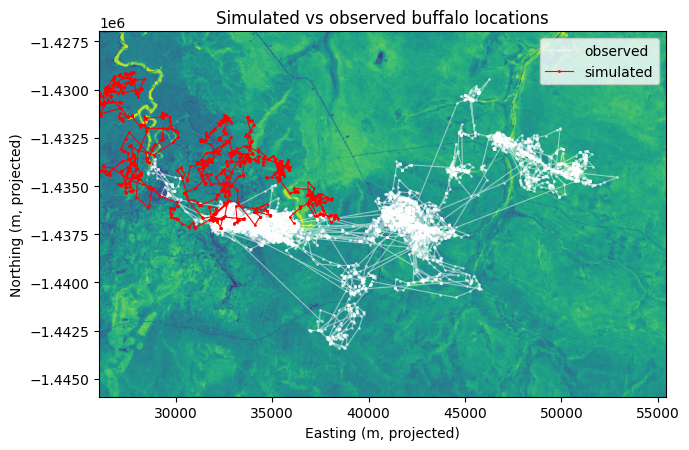

In [29]:
fig, ax = plt.subplots(figsize=(7, 6))
rasterio.plot.show(env_layers["ndvi"], transform=raster_transform, ax=ax, cmap='viridis')
ax.plot(
    step_df["x1_"], step_df["y1_"],
    "w-o", alpha=0.5, markersize=1, linewidth=0.8, label="observed",
)
ax.plot(
    sim_df["x"], sim_df["y"],
    "r-o", markersize=1, linewidth=0.8, label="simulated",
)
ax.set_xlabel("Easting (m, projected)")
ax.set_ylabel("Northing (m, projected)")
ax.legend()
ax.set_title("Simulated vs observed buffalo locations")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "simulated_trajectory.png"), dpi=100)
plt.show()